In [1]:
!pip install -r ../requirements.txt

In [23]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.sac as sac_agent
import configurations.config_p2_sub3 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(sac_agent)
importlib.reload(config_path)

device used:  cuda


<module 'configurations.config_p2_sub3' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p2_sub3.py'>

In [24]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.sac import DiscreteSAC
from configurations.config_p2_sub3 import config

In [25]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=2
)
sacAgent = DiscreteSAC(env, **config)

In [26]:
print(config)

{'gamma': 0.99, 'tau': 0.005, 'bufferSize': 100000, 'entropyLR': 0.0003, 'updateFrequency': 4, 'policyOptimizerFn': <class 'torch.optim.adam.Adam'>, 'valueOptimizerFn_1': <class 'torch.optim.adam.Adam'>, 'valueOptimizerFn_2': <class 'torch.optim.adam.Adam'>, 'policyOptimizerLR': 0.0003, 'valueOptimizerLR': 0.0003, 'alphaOptimizerFn': <class 'torch.optim.adam.Adam'>, 'MAX_TRAIN_EPISODES': 500, 'MAX_EVAL_EPISODE': 1, 'hDims': [256, 256], 'batchSize': 64, 'minSamples': 1000, 'device': device(type='cuda'), 'model_path': '../model_weights_phase2_sub3', 'target_entropy': np.float64(-0.8047189562170501)}


In [28]:
train_rewards, eval_scores, train_times = sacAgent.runSAC()

[Episode 1] Train reward Sum: -996.00
[Episode 2] Train reward Sum: -1000.00
[Episode 3] Train reward Sum: -972.00
[Episode 4] Train reward Sum: -1000.00
[Episode 5] Train reward Sum: -972.00
[Episode 6] Train reward Sum: -16800.00
[Episode 7] Train reward Sum: -10200.00
[Episode 8] Train reward Sum: -22400.00
[Episode 9] Train reward Sum: -28984.00
[Episode 10] Train reward Sum: -8584.00
[Episode 11] Train reward Sum: -10200.00
[Episode 12] Train reward Sum: -10972.00
[Episode 13] Train reward Sum: -972.00
[Episode 14] Train reward Sum: -22400.00
[Episode 15] Train reward Sum: -1000.00
[Episode 16] Train reward Sum: -34200.00
[Episode 17] Train reward Sum: -34984.00
[Episode 18] Train reward Sum: -1000.00
[Episode 19] Train reward Sum: -1000.00
[Episode 20] Train reward Sum: -1000.00
[Episode 21] Train reward Sum: -981.00
[Episode 22] Train reward Sum: 1180.00
[Episode 23] Train reward Sum: -33400.00
[Episode 24] Train reward Sum: -48000.00
[Episode 25] Train reward Sum: -1000.00
[Epi

In [29]:
print(f"SAC Final Evaluation Reward: {np.mean(eval_scores).item()} +- {np.std(eval_scores).item()}")

SAC Final Evaluation Reward: -1000.0 +- 0.0


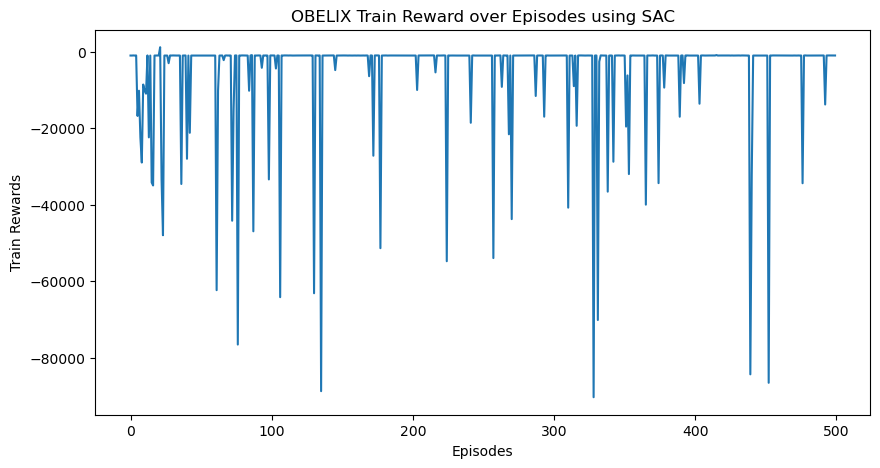

In [30]:
plotQuantity(
    train_rewards, 
    len(train_rewards), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using SAC"]    
)

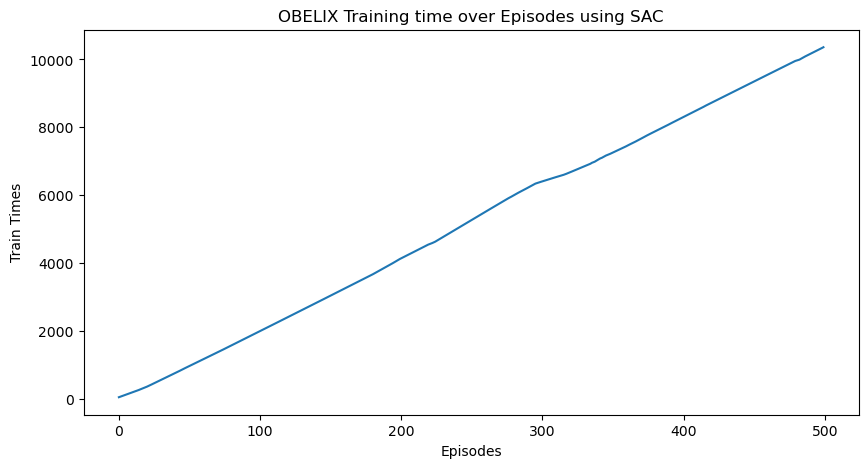

In [31]:
plotQuantity(
    train_times, 
    len(train_times), 
    descriptionList = ["Episodes", "Train Times", "OBELIX Training time over Episodes using SAC"]    
)